# libraries

In [ ]:
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt

# The Data

In [ ]:
df=pd.read_csv('/content/compas-scores-raw.csv')
df.head()

,Person_ID,AssessmentID,Case_ID,Agency_Text,LastName,FirstName,MiddleName,Sex_Code_Text,Ethnic_Code_Text,DateOfBirth,...,RecSupervisionLevel,RecSupervisionLevelText,Scale_ID,DisplayText,RawScore,DecileScore,ScoreText,AssessmentType,IsCompleted,IsDeleted
0,50844,57167,51950,PRETRIAL,Fisher,Kevin,NaN,Male,Caucasian,12/05/92,...,1,Low,7,Risk of Violence,-2.08,4,Low,New,1,0
1,50844,57167,51950,PRETRIAL,Fisher,Kevin,NaN,Male,Caucasian,12/05/92,...,1,Low,8,Risk of Recidivism,-1.06,2,Low,New,1,0
2,50844,57167,51950,PRETRIAL,Fisher,Kevin,NaN,Male,Caucasian,12/05/92,...,1,Low,18,Risk of Failure to Appear,15.00,1,Low,New,1,0
3,50848,57174,51956,PRETRIAL,KENDALL,KEVIN,NaN,Male,Caucasian,09/16/84,...,1,Low,7,Risk of Violence,-2.84,2,Low,New,1,0
4,50848,57174,51956,PRETRIAL,KENDALL,KEVIN,NaN,Male,Caucasian,09/16/84,...,1,Low,8,Risk of Recidivism,-1.50,1,Low,New,1,0


# Selected columns

In [ ]:
columns = ['Sex_Code_Text', 'Ethnic_Code_Text', 'DecileScore', 'ScoreText']
df = df[columns]


# Encoding



In [ ]:
label_encoders = {}
for column in ['Sex_Code_Text', 'Ethnic_Code_Text', 'ScoreText']:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le

#Define The Target

In [ ]:
X = df.drop('ScoreText', axis=1)
y = df['ScoreText']

# Scale features

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#KFold

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Logistic Regression

In [ ]:
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg_accuracies = []
log_reg_f1_scores = []

for train_index, val_index in kf.split(X_scaled):
    X_train, X_val = X_scaled[train_index], X_scaled[val_index]
    y_train, y_val = y[train_index], y[val_index]

    log_reg.fit(X_train, y_train)
    y_val_pred = log_reg.predict(X_val)
    log_reg_accuracies.append(accuracy_score(y_val, y_val_pred))
    log_reg_f1_scores.append(f1_score(y_val, y_val_pred, average='weighted'))

print("Logistic Regression:")
print(f"  Cross-Validation Accuracy: {sum(log_reg_accuracies) / len(log_reg_accuracies):.4f}")
print(f"  Cross-Validation F1 Score: {sum(log_reg_f1_scores) / len(log_reg_f1_scores):.4f}\n")

Logistic Regression:
  Cross-Validation Accuracy: 0.9993
  Cross-Validation F1 Score: 0.9989



# K-Nearest Neighbors (KNN)

In [ ]:
knn = KNeighborsClassifier()
knn_accuracies = []
knn_f1_scores = []

for train_index, val_index in kf.split(X_scaled):
    X_train, X_val = X_scaled[train_index], X_scaled[val_index]
    y_train, y_val = y[train_index], y[val_index]

    knn.fit(X_train, y_train)
    y_val_pred = knn.predict(X_val)
    knn_accuracies.append(accuracy_score(y_val, y_val_pred))
    knn_f1_scores.append(f1_score(y_val, y_val_pred, average='weighted'))

print("K-Nearest Neighbors (KNN):")
print(f"  Cross-Validation Accuracy: {sum(knn_accuracies) / len(knn_accuracies):.4f}")
print(f"  Cross-Validation F1 Score: {sum(knn_f1_scores) / len(knn_f1_scores):.4f}\n")

K-Nearest Neighbors (KNN):
  Cross-Validation Accuracy: 0.9997
  Cross-Validation F1 Score: 0.9997



# Ridge Classifier

In [ ]:
ridge = RidgeClassifier(random_state=42)
ridge_accuracies = []
ridge_f1_scores = []

for train_index, val_index in kf.split(X_scaled):
    X_train, X_val = X_scaled[train_index], X_scaled[val_index]
    y_train, y_val = y[train_index], y[val_index]

    ridge.fit(X_train, y_train)
    y_val_pred = ridge.predict(X_val)
    ridge_accuracies.append(accuracy_score(y_val, y_val_pred))
    ridge_f1_scores.append(f1_score(y_val, y_val_pred, average='weighted'))

print("Ridge Classifier:")
print(f"  Cross-Validation Accuracy: {sum(ridge_accuracies) / len(ridge_accuracies):.4f}")
print(f"  Cross-Validation F1 Score: {sum(ridge_f1_scores) / len(ridge_f1_scores):.4f}\n")

Ridge Classifier:
  Cross-Validation Accuracy: 0.8509
  Cross-Validation F1 Score: 0.8349



# lists

In [ ]:
models = ["Logistic Regression", "K-Nearest Neighbors (KNN)", "Ridge Classifier"]
accuracies = [
    sum(log_reg_accuracies) / len(log_reg_accuracies),
    sum(knn_accuracies) / len(knn_accuracies),
    sum(ridge_accuracies) / len(ridge_accuracies)
]
f1_scores = [
    sum(log_reg_f1_scores) / len(log_reg_f1_scores),
    sum(knn_f1_scores) / len(knn_f1_scores),
    sum(ridge_f1_scores) / len(ridge_f1_scores)
]

# Accuracy

([0, 1, 2],
 [Text(0, 0, 'Logistic Regression'),
  Text(1, 0, 'K-Nearest Neighbors (KNN)'),
  Text(2, 0, 'Ridge Classifier')])

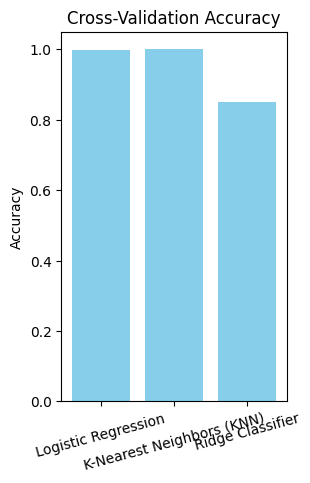

In [ ]:
plt.subplot(1, 2, 1)
plt.bar(models, accuracies, color='skyblue')
plt.title("Cross-Validation Accuracy")
plt.ylabel("Accuracy")
plt.xticks(rotation=15)

#F1-score

([0, 1, 2],
 [Text(0, 0, 'Logistic Regression'),
  Text(1, 0, 'K-Nearest Neighbors (KNN)'),
  Text(2, 0, 'Ridge Classifier')])

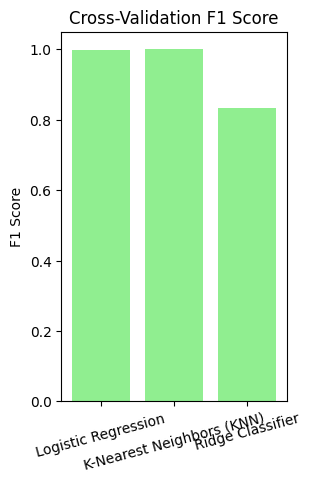

In [ ]:
plt.subplot(1, 2, 2)
plt.bar(models, f1_scores, color='lightgreen')
plt.title("Cross-Validation F1 Score")
plt.ylabel("F1 Score")
plt.xticks(rotation=15)